## 一、匯入套件與cleaned data

In [1]:
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import warnings
from pathlib import Path
import plotly.express as px  # 用於動態交互式繪圖
from pathlib import Path


def find_cjk_font() -> str:
    # 1. Repo-bundled fonts (works on all platforms after git clone)
    for repo_path in Path('fonts').glob('*.tt[cf]') if Path('fonts').exists() else []:
        fm.fontManager.addfont(str(repo_path))
        name = fm.FontProperties(fname=str(repo_path)).get_name()
        print(f'✓ Using repo font: {name}')
        return name

    # 2. OS-specific system fonts
    system = platform.system()
    candidates = {
        'Darwin': [                                       # macOS
            '/Library/Fonts/SourceHanSerif-SemiBold.ttc',
            '/Library/Fonts/SourceHanSans-Regular.ttc',
            '/System/Library/Fonts/STHeiti Medium.ttc',
            '/Library/Fonts/Arial Unicode.ttf',
        ],
        'Windows': [                                      # Windows
            r'C:\Windows\Fonts\msjh.ttc',                # 微軟正黑體 (Traditional Chinese)
            r'C:\Windows\Fonts\mingliu.ttc',             # 細明體
            r'C:\Windows\Fonts\kaiu.ttf',                # 標楷體
        ],
        'Linux': [                                        # Linux / Colab
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
        ],
    }.get(system, [])

    for path in candidates:
        if Path(path).exists():
            fm.fontManager.addfont(path)
            name = fm.FontProperties(fname=path).get_name()
            print(f'✓ Using system font: {name} ({path})')
            return name

    # 3. Search installed fonts for any CJK-capable font
    cjk_keywords = ['CJK', 'Chinese', 'Gothic', 'Heiti', 'Noto Sans CJK',
                     'Microsoft JhengHei', 'MingLiU', 'Source Han']
    for f in fm.fontManager.ttflist:
        if any(kw.lower() in f.name.lower() for kw in cjk_keywords):
            print(f'✓ Using installed font: {f.name}')
            return f.name

    print('⚠ No CJK font found — Chinese labels may show as boxes.')
    return 'sans-serif'

font_name = find_cjk_font()
plt.rcParams['font.family']        = font_name
plt.rcParams['font.weight']        = 'bold'
plt.rcParams['axes.titleweight']   = 'bold'
plt.rcParams['axes.labelweight']   = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'
matplotlib.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

✓ Using system font: Source Han Serif (/Library/Fonts/SourceHanSerif-SemiBold.ttc)


In [2]:
# 匯入cleaned data
df_ac = pd.read_parquet('cleaned_data/ac_普通.parquet')
df_putong1 = pd.read_parquet('cleaned_data/putong1_普通新設一.parquet')
df_putong2 = pd.read_parquet('cleaned_data/putong2_普通新設二.parquet')
df_elevator = pd.read_parquet('cleaned_data/elevator_普通電梯.parquet')
df_gongtong = pd.read_parquet('cleaned_data/gongtong_共同教室.parquet')
df_boya1 = pd.read_parquet('cleaned_data/boya1_博雅館一.parquet')
df_boya2 = pd.read_parquet('cleaned_data/boya2_博雅館二.parquet')
df_boya3 = pd.read_parquet('cleaned_data/boya3_博雅三.parquet')
df_boya4 = pd.read_parquet('cleaned_data/boya3_博雅三.parquet')
df_xinsheng = pd.read_parquet('cleaned_data/xinsheng_新生大樓.parquet')
weather = pd.read_csv('cleaned_data/weather_data_2016_2025.csv')
                              

## 二、普通分析

### 1.合併電表與溫度資料

In [3]:
# 合併電表與溫度
putong_all = pd.concat([
    df_ac[['kw']].rename(columns={'kw': 'ac'}),
    df_putong1[['kw']].rename(columns={'kw': 'm1'}),
    df_putong2[['kw']].rename(columns={'kw': 'm2'}),
    df_elevator[['kw']].rename(columns={'kw': 'diantee'}),
], axis=1)
df_weather = weather.set_index('ObsTime')
df_weather.index= pd.to_datetime(df_weather.index)
df_ac.index= pd.to_datetime(df_ac.index)


putong_all_weather = pd.concat([putong_all, df_weather], axis=1)
putong_all_weather

,ac,m1,m2,diantee,StnPres,SeaPres,Temperature,Td dew point,RH,WS,...,Cloud Amount Sat,TxSoil0cm,TxSoil5cm,TxSoil10cm,TxSoil20cm,TxSoil30cm,TxSoil50cm,TxSoil100cm,WSGust,WDGust
2016-01-01 00:00:00,5.74,6.28,0.14,0.08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-01 01:00:00,5.91,7.00,0.15,0.08,1024.60,1028.30,16.70,11.80,73.00,4.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.70,60.00
2016-01-01 02:00:00,6.16,4.56,0.14,0.07,1024.10,1027.80,16.60,12.30,76.00,3.70,...,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.00,70.00
2016-01-01 03:00:00,6.44,5.80,0.14,0.08,1023.70,1027.40,17.00,12.10,73.00,3.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.70,70.00
2016-01-01 04:00:00,6.65,4.43,0.14,0.08,1023.60,1027.30,16.70,12.50,76.00,3.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.70,40.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:00:00,4.30,3.15,0.00,0.07,1013.30,1016.90,17.10,16.00,93.00,2.80,...,NaN,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,6.30,86.00
2025-12-31 22:00:00,4.47,1.64,0.00,0.07,1013.40,1017.00,17.20,15.60,90.00,1.60,...,NaN,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,6.70,97.00
2025-12-31 23:00:00,4.88,2.06,0.00,0.07,1013.60,1017.20,16.90,15.60,92.00,0.90,...,NaN,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,4.10,68.00
2025-12-31 23:59:00,NaN,NaN,NaN,NaN,1013.10,1016.70,16.70,15.60,93.00,0.90,...,NaN,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,-99.50,5.90,94.00


### 2.分出usage type(用電情境)

In [4]:
# 1. 先取出小時資訊
hour = putong_all_weather.index.hour
temp = putong_all_weather['Temperature']

# 2. 定義四個分類的條件
conditions = [
    # 第一類：冷季凌晨用電 (00:00 - 06:00, temp < 18.9)
    (hour >= 0) & (hour < 6) & (temp < 18.9),
    
    # 第二類：冷季下午用電 (12:00 - 18:00, temp < 20.5)
    (hour >= 12) & (hour < 18) & (temp < 20.5),
    
    # 第三類：暖季凌晨用電 (00:00 - 06:00, temp > 28.5)
    (hour >= 0) & (hour < 6) & (temp > 28.5),
    
    # 第四類：暖季下午用電 (12:00 - 18:00, temp > 31.4)
    (hour >= 12) & (hour < 18) & (temp > 31.4)
]

# 3. 定義對應的名稱
choices = [
    '冷季凌晨用電',
    '冷季下午用電',
    '暖季凌晨用電',
    '暖季下午用電'
]

# 4. 建立新欄位 'usage_type'，若不符合以上條件則標記為 '其他'
putong_all_weather['usage_type'] = np.select(conditions, choices, default='其他')



### 3.分出日型與情境

In [5]:
month = putong_all_weather.index.month

# 1. 定義日期清單 (已從您的輸入中去重並整理)
national_holidays = [
    "2016-01-01","2016-02-28","2016-02-29","2016-04-04","2016-04-05","2016-06-09","2016-09-15","2016-10-10",
    "2017-01-01","2017-01-02","2017-02-28","2017-04-04","2017-05-30","2017-10-04","2017-10-10",
    "2018-01-01","2018-02-28","2018-04-04","2018-04-05","2018-06-18","2018-09-24","2018-10-10",
    "2019-01-01","2019-02-28","2019-04-04","2019-04-05","2019-06-07","2019-09-13","2019-10-10",
    "2020-01-01","2020-02-28","2020-04-02","2020-04-03","2020-04-04","2020-04-05","2020-06-25","2020-10-01","2020-10-09","2020-10-10","2020-10-11",
    "2021-01-01","2021-02-28","2021-03-01","2021-04-02","2021-04-03","2021-04-04","2021-04-05","2021-06-14","2021-09-21","2021-10-10","2021-10-11",
    "2022-01-01","2022-02-28","2022-04-02","2022-04-03","2022-04-04","2022-04-05","2022-06-03","2022-09-10","2022-10-10",
    "2023-01-01","2023-01-02","2023-02-28","2023-04-01","2023-04-02","2023-04-03","2023-04-04","2023-04-05","2023-06-22","2023-09-29","2023-10-10",
    "2024-01-01","2024-02-28","2024-04-04","2024-04-05","2024-04-06","2024-04-07","2024-06-10","2024-09-17","2024-10-10",
    "2025-01-01","2025-02-28","2025-04-03","2025-04-04","2025-04-05","2025-04-06","2025-05-31","2025-10-06","2025-10-10"
]
cny_holidays = [
    "2016-02-07","2016-02-08","2016-02-09","2016-02-10","2016-02-11","2016-02-12",
    "2017-01-27","2017-01-28","2017-01-29","2017-01-30","2017-01-31","2017-02-01",
    "2018-02-15","2018-02-16","2018-02-17","2018-02-18","2018-02-19","2018-02-20",
    "2019-02-04","2019-02-05","2019-02-06","2019-02-07","2019-02-08","2019-02-09",
    "2020-01-24","2020-01-25","2020-01-26","2020-01-27","2020-01-28","2020-01-29",
    "2021-02-11","2021-02-12","2021-02-13","2021-02-14","2021-02-15","2021-02-16",
    "2022-01-31","2022-02-01","2022-02-02","2022-02-03","2022-02-04","2022-02-05",
    "2023-01-21","2023-01-22","2023-01-23","2023-01-24","2023-01-25","2023-01-26",
    "2024-02-09","2024-02-10","2024-02-11","2024-02-12","2024-02-13","2024-02-14",
    "2025-01-28","2025-01-29","2025-01-30","2025-01-31","2025-02-01","2025-02-02"
]

# 2. 轉換為 Set 提升查詢效率
national_holiday_set = set(national_holidays)
cny_holiday_set = set(cny_holidays)

def get_day_type(dt):
    """
    輸入: datetime 物件
    輸出: 0=平日, 1=過年, 2=例假日, 3=寒暑假
    """
    date_str = dt.strftime('%Y-%m-%d')
    
    # 優先級：過年 > 寒暑假 > 週末與國定假日 > 平日
    if date_str in cny_holiday_set:
        return 1 # 過年
    elif dt.month in [1, 2, 7, 8]:
        return 3  # 寒暑假
    elif date_str in national_holiday_set or dt.weekday() >= 5:
        return 2 # 週末與國定假日
    else :
        return 0

# 3. 使用範例 (假設您有一個 DataFrame 叫 df，裡面有 'datetime' 欄位)
putong_all_weather['DayType'] = putong_all_weather.index.map(get_day_type)
putong_all_weather['DayType'] 

2016-01-01 00:00:00    3
2016-01-01 01:00:00    3
2016-01-01 02:00:00    3
2016-01-01 03:00:00    3
2016-01-01 04:00:00    3
                      ..
2025-12-31 21:00:00    0
2025-12-31 22:00:00    0
2025-12-31 23:00:00    0
2025-12-31 23:59:00    0
2026-01-01 00:00:00    3
Name: DayType, Length: 91326, dtype: int64

In [6]:
# 結合usage type和daytype分出十六種類

usage_map = {
    '冷季凌晨用電': 'a',
    '冷季下午用電': 'b',
    '暖季凌晨用電': 'c',
    '暖季下午用電': 'd'
}

daytype_map = {
    0: '0',
    1: '1',
    2: '2',
    3: '3'
}

# 建立新欄位：直接將兩個轉換後的字串相加
# 如果 usage 或 daytype 不在字典中，會回傳 NaN
putong_all_weather['type_code'] = putong_all_weather['usage_type'].map(usage_map) + putong_all_weather['DayType'].map(daytype_map)

### 4.計算分項用電

In [7]:
# 普通各電表加總得出總用電量
putong_all_weather['kWh'] = putong_all_weather[['ac', 'm1', 'm2', 'diantee']].sum(axis=1)

In [8]:
# 計算十六個用電情境+日型的用電量
kWh_sum = putong_all_weather.groupby('type_code')['kWh'].sum()

# 取出用電量的值
a1 = kWh_sum.get('a0', 0)
a2 = kWh_sum.get('a1', 0)
a3 = kWh_sum.get('a2', 0)
a4 = kWh_sum.get('a3', 0)

b1 = kWh_sum.get('b0', 0)
b2 = kWh_sum.get('b1', 0)
b3 = kWh_sum.get('b2', 0)
b4 = kWh_sum.get('b3', 0)

c1 = kWh_sum.get('c0', 0)
c2 = kWh_sum.get('c1', 0)
c3 = kWh_sum.get('c2', 0)
c4 = kWh_sum.get('c3', 0)

d1 = kWh_sum.get('d0', 0)
d2 = kWh_sum.get('d1', 0)
d3 = kWh_sum.get('d2', 0)
d4 = kWh_sum.get('d3', 0)

In [9]:
kWh_sum

type_code
a0    19469.29
a1     2503.85
a2     7165.82
a3    30613.08
b0    85033.96
b1     1742.54
b2    15499.49
b3    57805.02
c0     4905.15
c2     2075.37
c3    17160.92
d0   231465.61
d2    32625.70
d3   200120.32
Name: kWh, dtype: float64

In [10]:
# A.凌晨用電最低值
A=min(a1, a2, a3, a4)

# B.下午用電最低值
B=min(b1, b2, b3, b4)

# C.設備基本待機用電
X = sorted([a1, a2, a3, a4])[1]
C=max(X-A,0)

# D.設備待機用電增量(暖)
Y=min(c1, c2, c3, c4)
D=max(Y-A-C,0)

# E.上班/研究用電
Z=min(b1, b4)
E=max(Z-B-C,0)

# F.上課用電
F=max(b1-B-C-E,0)

# G.上班/研究空調用電
G=max(d4-B-C-D-E,0)

# H.上課空調用電
H=max(d1-B-C-D-E-F-G,0)

In [11]:
print(A,B,C,D,E,F,G,H)

2503.85 1742.537142857143 4661.975 0 51400.50945238095 27228.93930159841 142315.29464668618 4116.353928579658


### 5.組合分項用電

In [12]:
館舍基礎用電 = A
設備待機用電 = C+D
人員設備使用用電 = E+F
人員空調使用用電 = G+H

In [13]:
print("館舍基礎用電:", 館舍基礎用電)
print("設備待機用電:", 設備待機用電)
print("人員設備使用用電:", 人員設備使用用電)
print("人員空調使用用電:", 人員空調使用用電)

館舍基礎用電: 2503.85
設備待機用電: 4661.975
人員設備使用用電: 78629.44875397936
人員空調使用用電: 146431.64857526583


## 三、補充分析（設定溫度推算 + EDA 視覺化）

### 2. 拐點散佈圖：普通 AC kW vs 室外溫度

目的：找出冷氣開始大量運作的溫度折點 → 推算現行有效設定溫度（CDH 反事實的輸入）

分析邏輯：
- 只看上課時段（08:00–22:00）、上課日（DayType=0）以過濾無人時段干擾  
- 溫度 < 20°C 時 AC 用電應趨近基礎值，折點之後才反映冷氣啟動


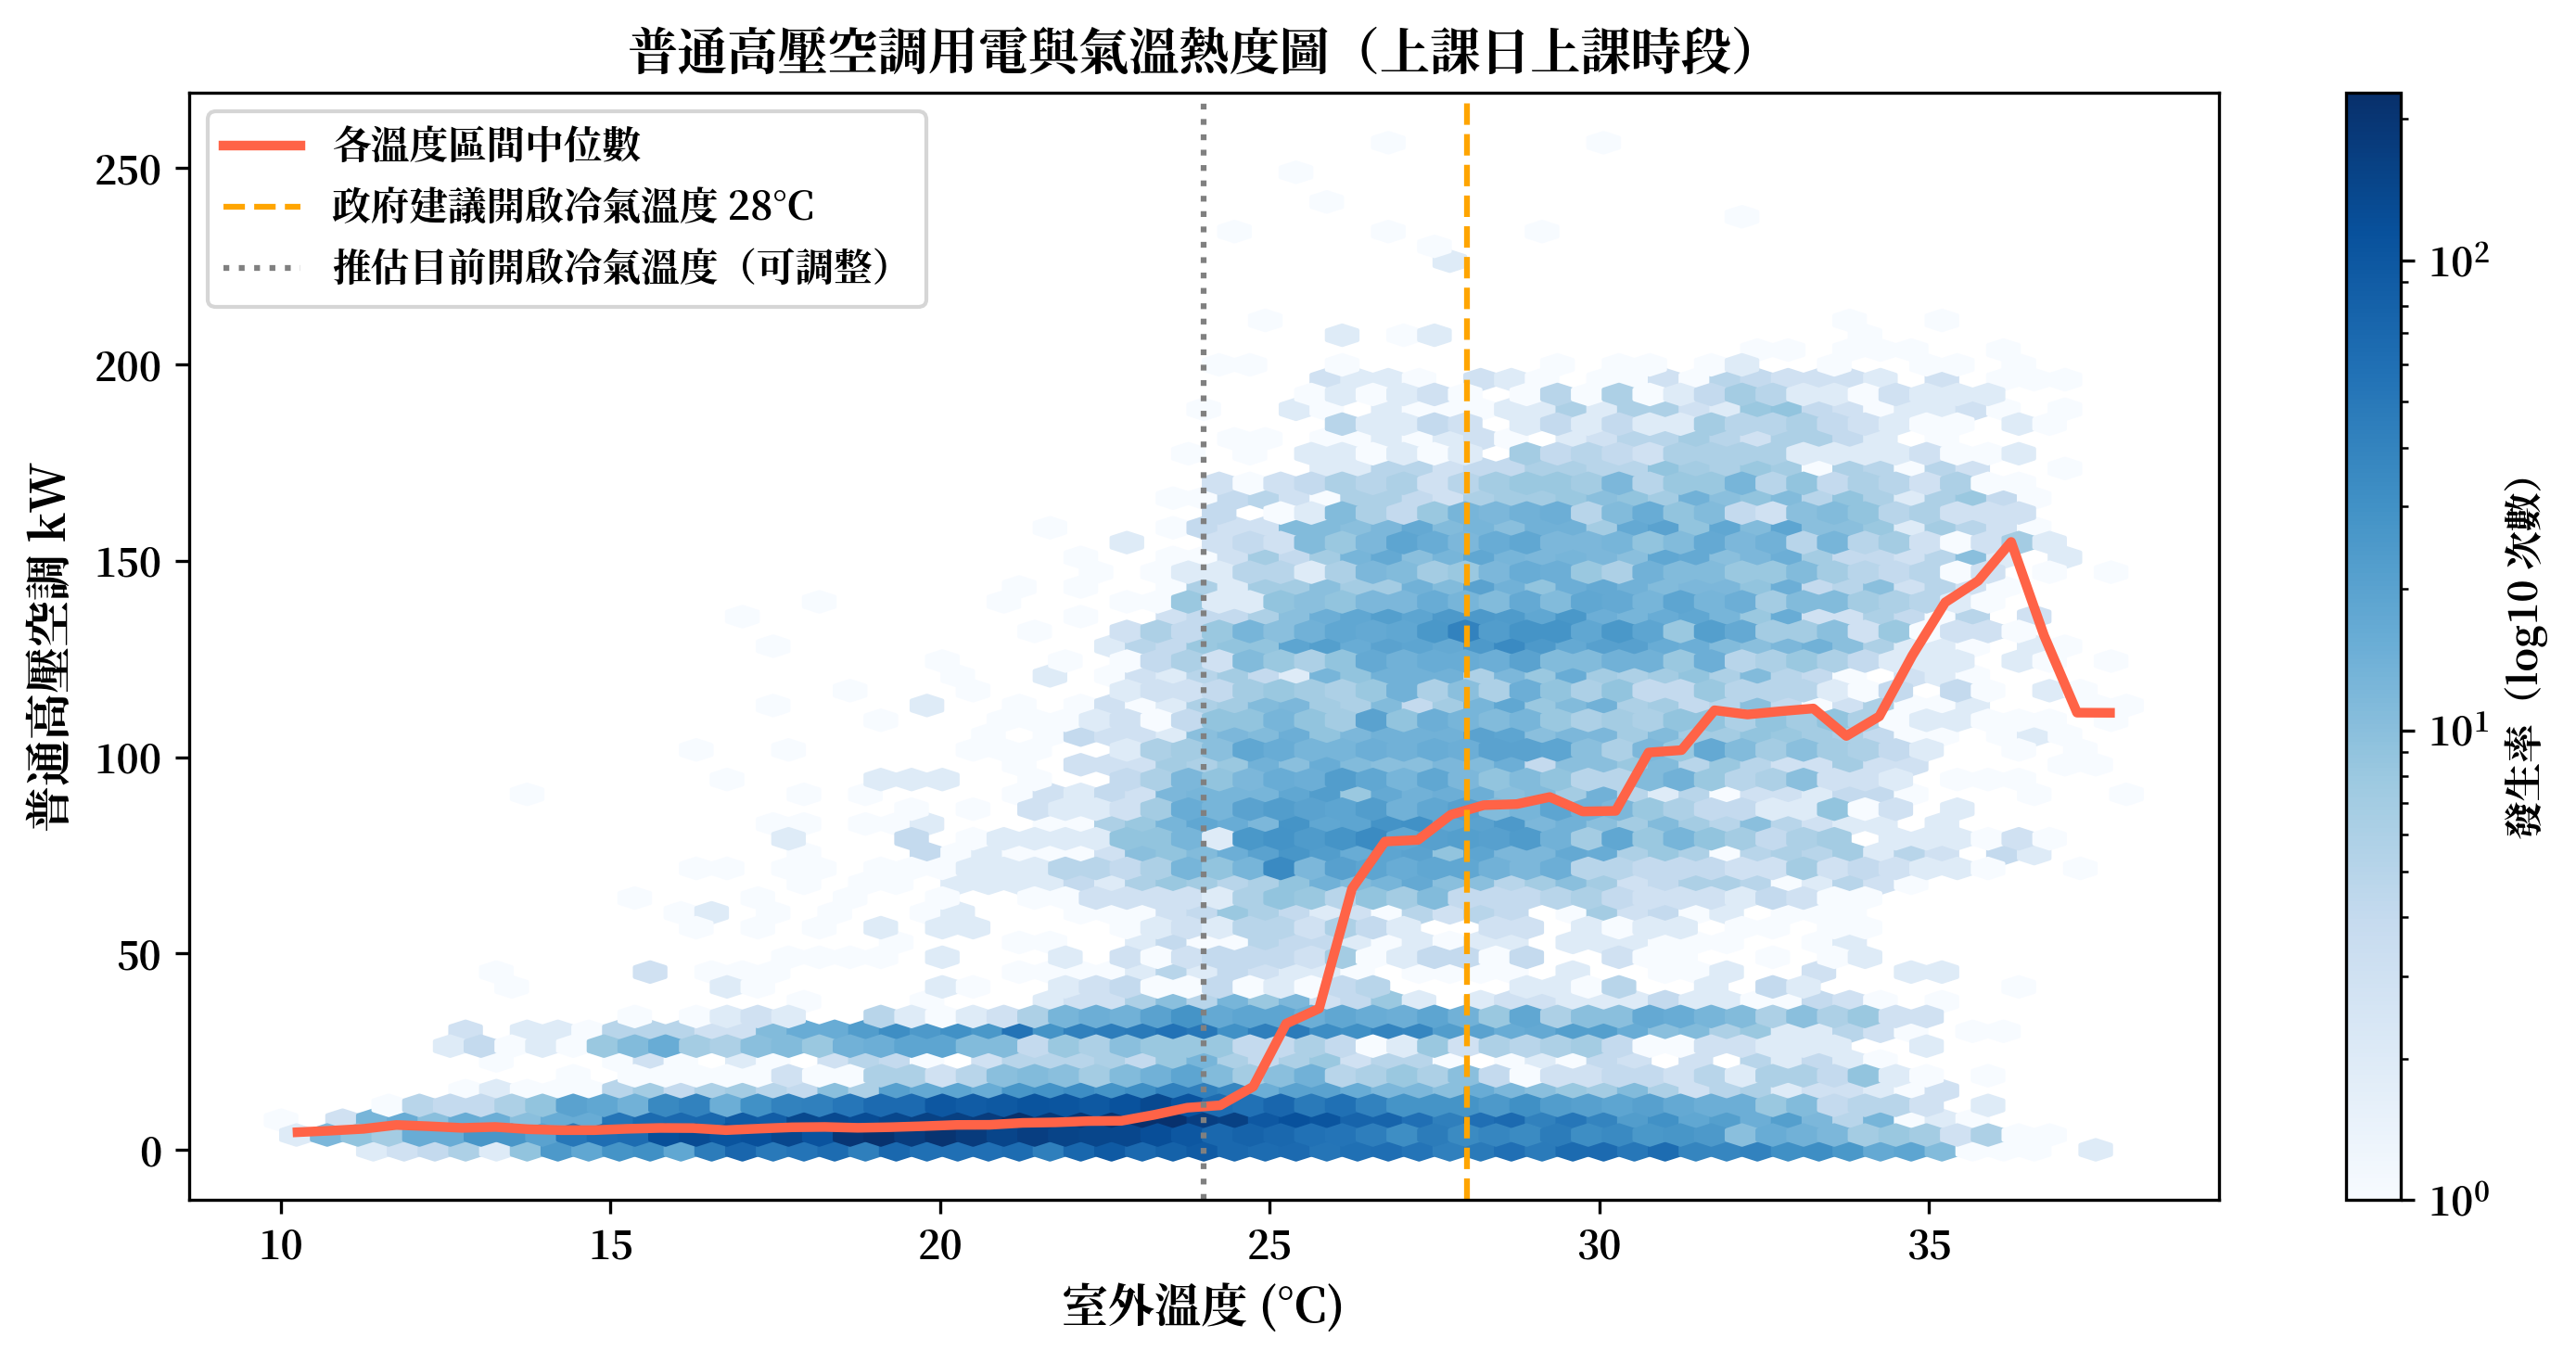


▶ 請觀察趨勢線折點，即為推估的現行有效設定溫度
  折點左側（低溫）：AC 維持基礎用電；折點右側：用電隨溫度線性增加


In [25]:
from scipy.stats import binned_statistic

# 篩選：上課日 + 上課時段
mask = (
    (putong_all_weather['DayType'] == 0) &
    (putong_all_weather.index.hour >= 8) &
    (putong_all_weather.index.hour <= 22) &
    putong_all_weather['Temperature'].notna() &
    putong_all_weather['ac'].notna()
)
scatter_df = putong_all_weather[mask][['Temperature', 'ac']].copy()
scatter_df = scatter_df[(scatter_df['Temperature'] >= 10) & (scatter_df['Temperature'] <= 38)]

# 每 0.5°C 溫度區間的中位數
bins = [round(x * 0.5, 1) for x in range(20, 77)]  # 10°C ~ 38°C
bin_med, bin_edges, _ = binned_statistic(
    scatter_df['Temperature'], scatter_df['ac'],
    statistic='median', bins=bins
)
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges)-1)]

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Hexbin 密度熱圖（取代散點）
hb = ax.hexbin(
    scatter_df['Temperature'],
    scatter_df['ac'],
    gridsize=60,
    cmap='Blues',
    mincnt=1,
    bins='log'
)
cb = fig.colorbar(hb, ax=ax)
cb.set_label('發生率（log10 次數）')

# 中位數趨勢線
ax.plot(bin_centers, bin_med, color='tomato', linewidth=2.5, label='各溫度區間中位數')

# 標記推估折點（目視輔助線，可依實際結果調整）
ax.axvline(x=28, color='orange', linestyle='--', linewidth=1.5, label='政府建議開啟冷氣溫度 28°C')
ax.axvline(x=24, color='gray', linestyle=':', linewidth=1.5, label='推估目前開啟冷氣溫度（可調整）')

ax.set_xlabel('室外溫度 (°C)', fontsize=12)
ax.set_ylabel('普通高壓空調 kW', fontsize=12)
ax.set_title('普通高壓空調用電與氣溫熱度圖（上課日上課時段）', fontsize=13)
ax.legend(loc = 'upper left')
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)


plt.tight_layout()
plt.savefig('cleaned_data/inflection_point.png', dpi=300)
plt.show()
print("\n▶ 請觀察趨勢線折點，即為推估的現行有效設定溫度")
print("  折點左側（低溫）：AC 維持基礎用電；折點右側：用電隨溫度線性增加")


### 3. 各館舍用電熱力圖（月份 × 時段）

目的：視覺化每棟教學館的用電模式，找出高用電時段 → 支持「時段管制」政策


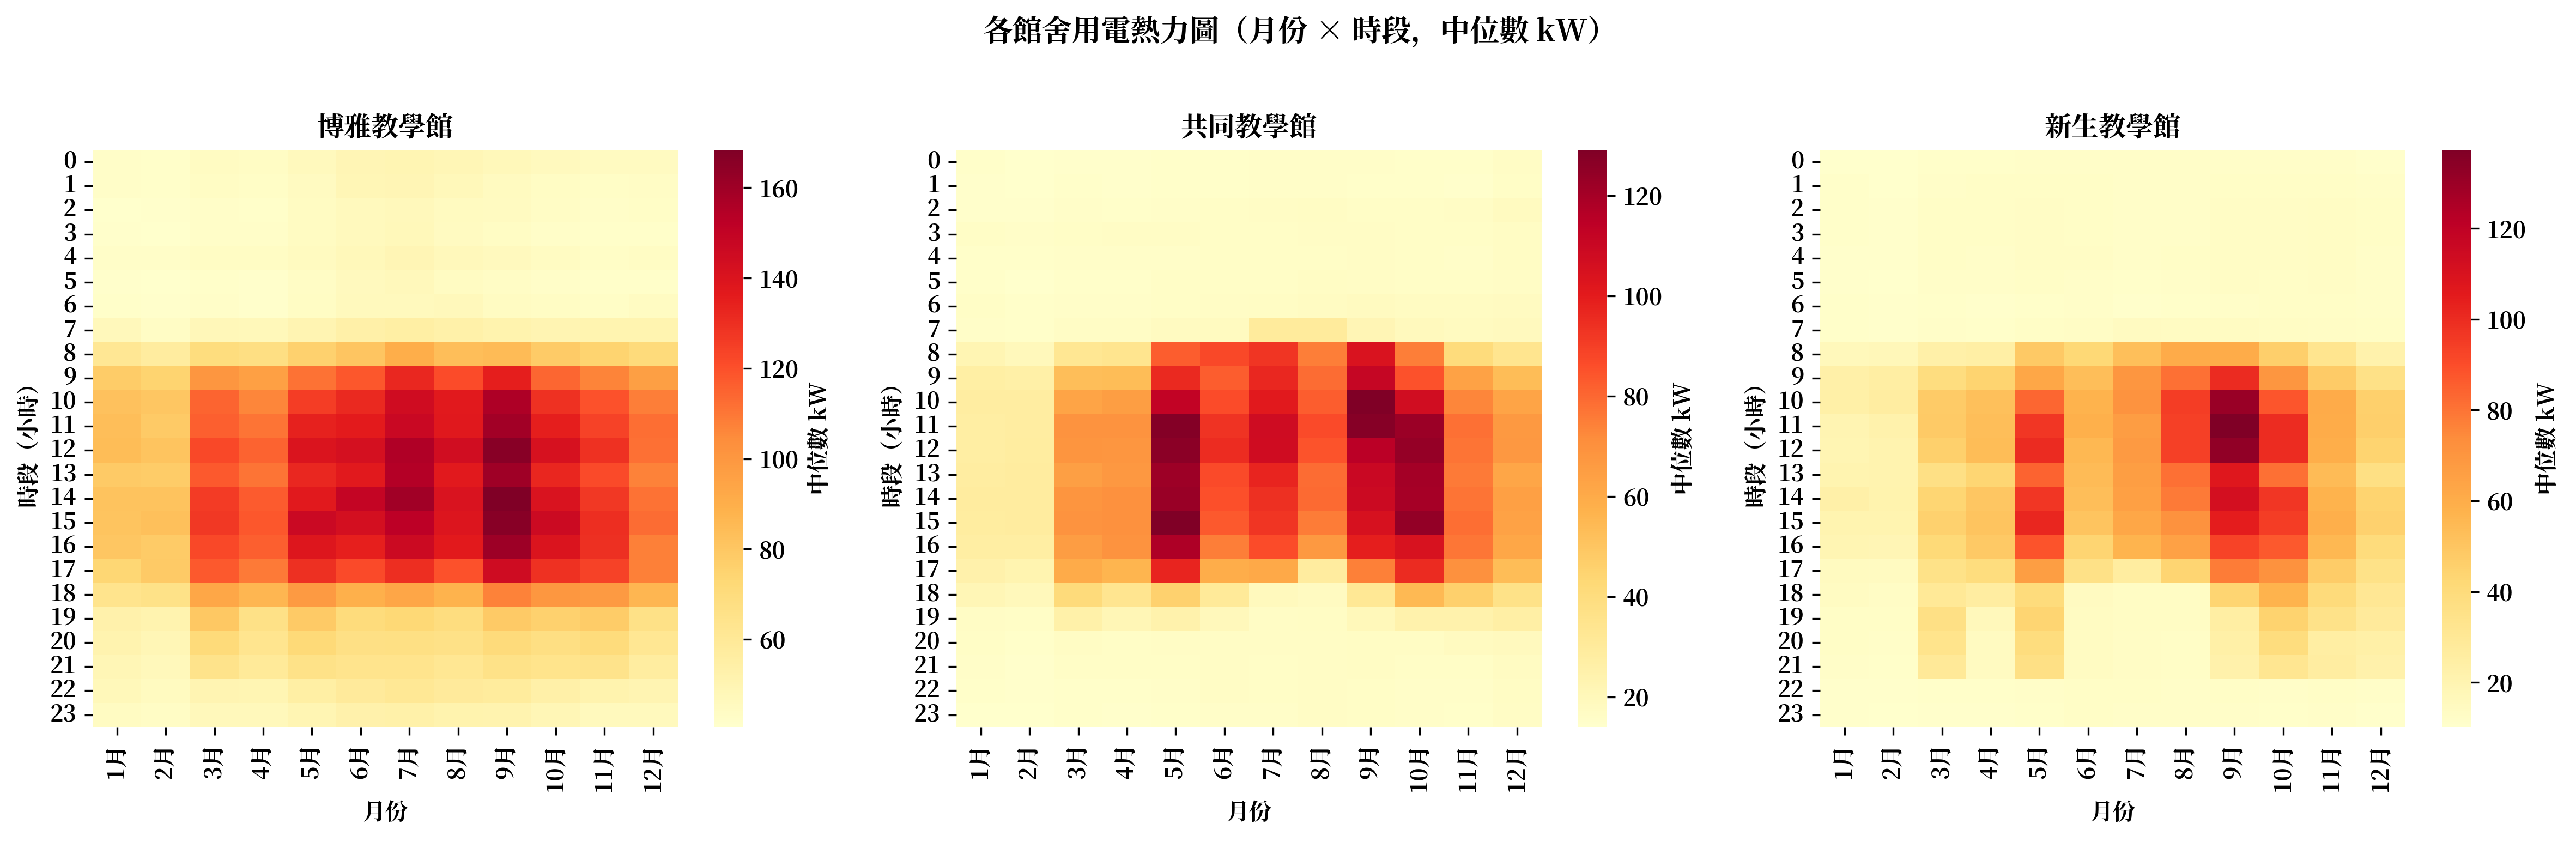

In [29]:
# 合併各館舍資料，統一格式
buildings = {
    '博雅': pd.concat([df_boya1[['kw']], df_boya2[['kw']], df_boya3[['kw']], df_boya4[['kw']]]).groupby(level=0)['kw'].sum().rename('kw'),
    '共同': df_gongtong['kw'],
    '新生': df_xinsheng['kw'],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi = 300)

for ax, (name, series) in zip(axes, buildings.items()):
    df_heat = series.to_frame()
    df_heat['month'] = df_heat.index.month
    df_heat['hour'] = df_heat.index.hour
    pivot = df_heat.groupby(['hour', 'month'])['kw'].median().unstack(level='month')
    pivot.columns = [f'{m}月' for m in pivot.columns]

    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0,
                cbar_kws={'label': '中位數 kW'})
    ax.set_title(f'{name}教學館', fontsize=12)
    ax.set_xlabel('月份')
    ax.set_ylabel('時段（小時）')

plt.suptitle('各館舍用電熱力圖（月份 × 時段，中位數 kW）', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cleaned_data/heatmap_buildings.png', dpi=150, bbox_inches='tight')
plt.show()


### 4. 假日 vs 平日負載曲線比較

目的：若假日用電與平日相差不大，代表冷氣在無人時段仍持續運作 → 直接呈現政策缺口


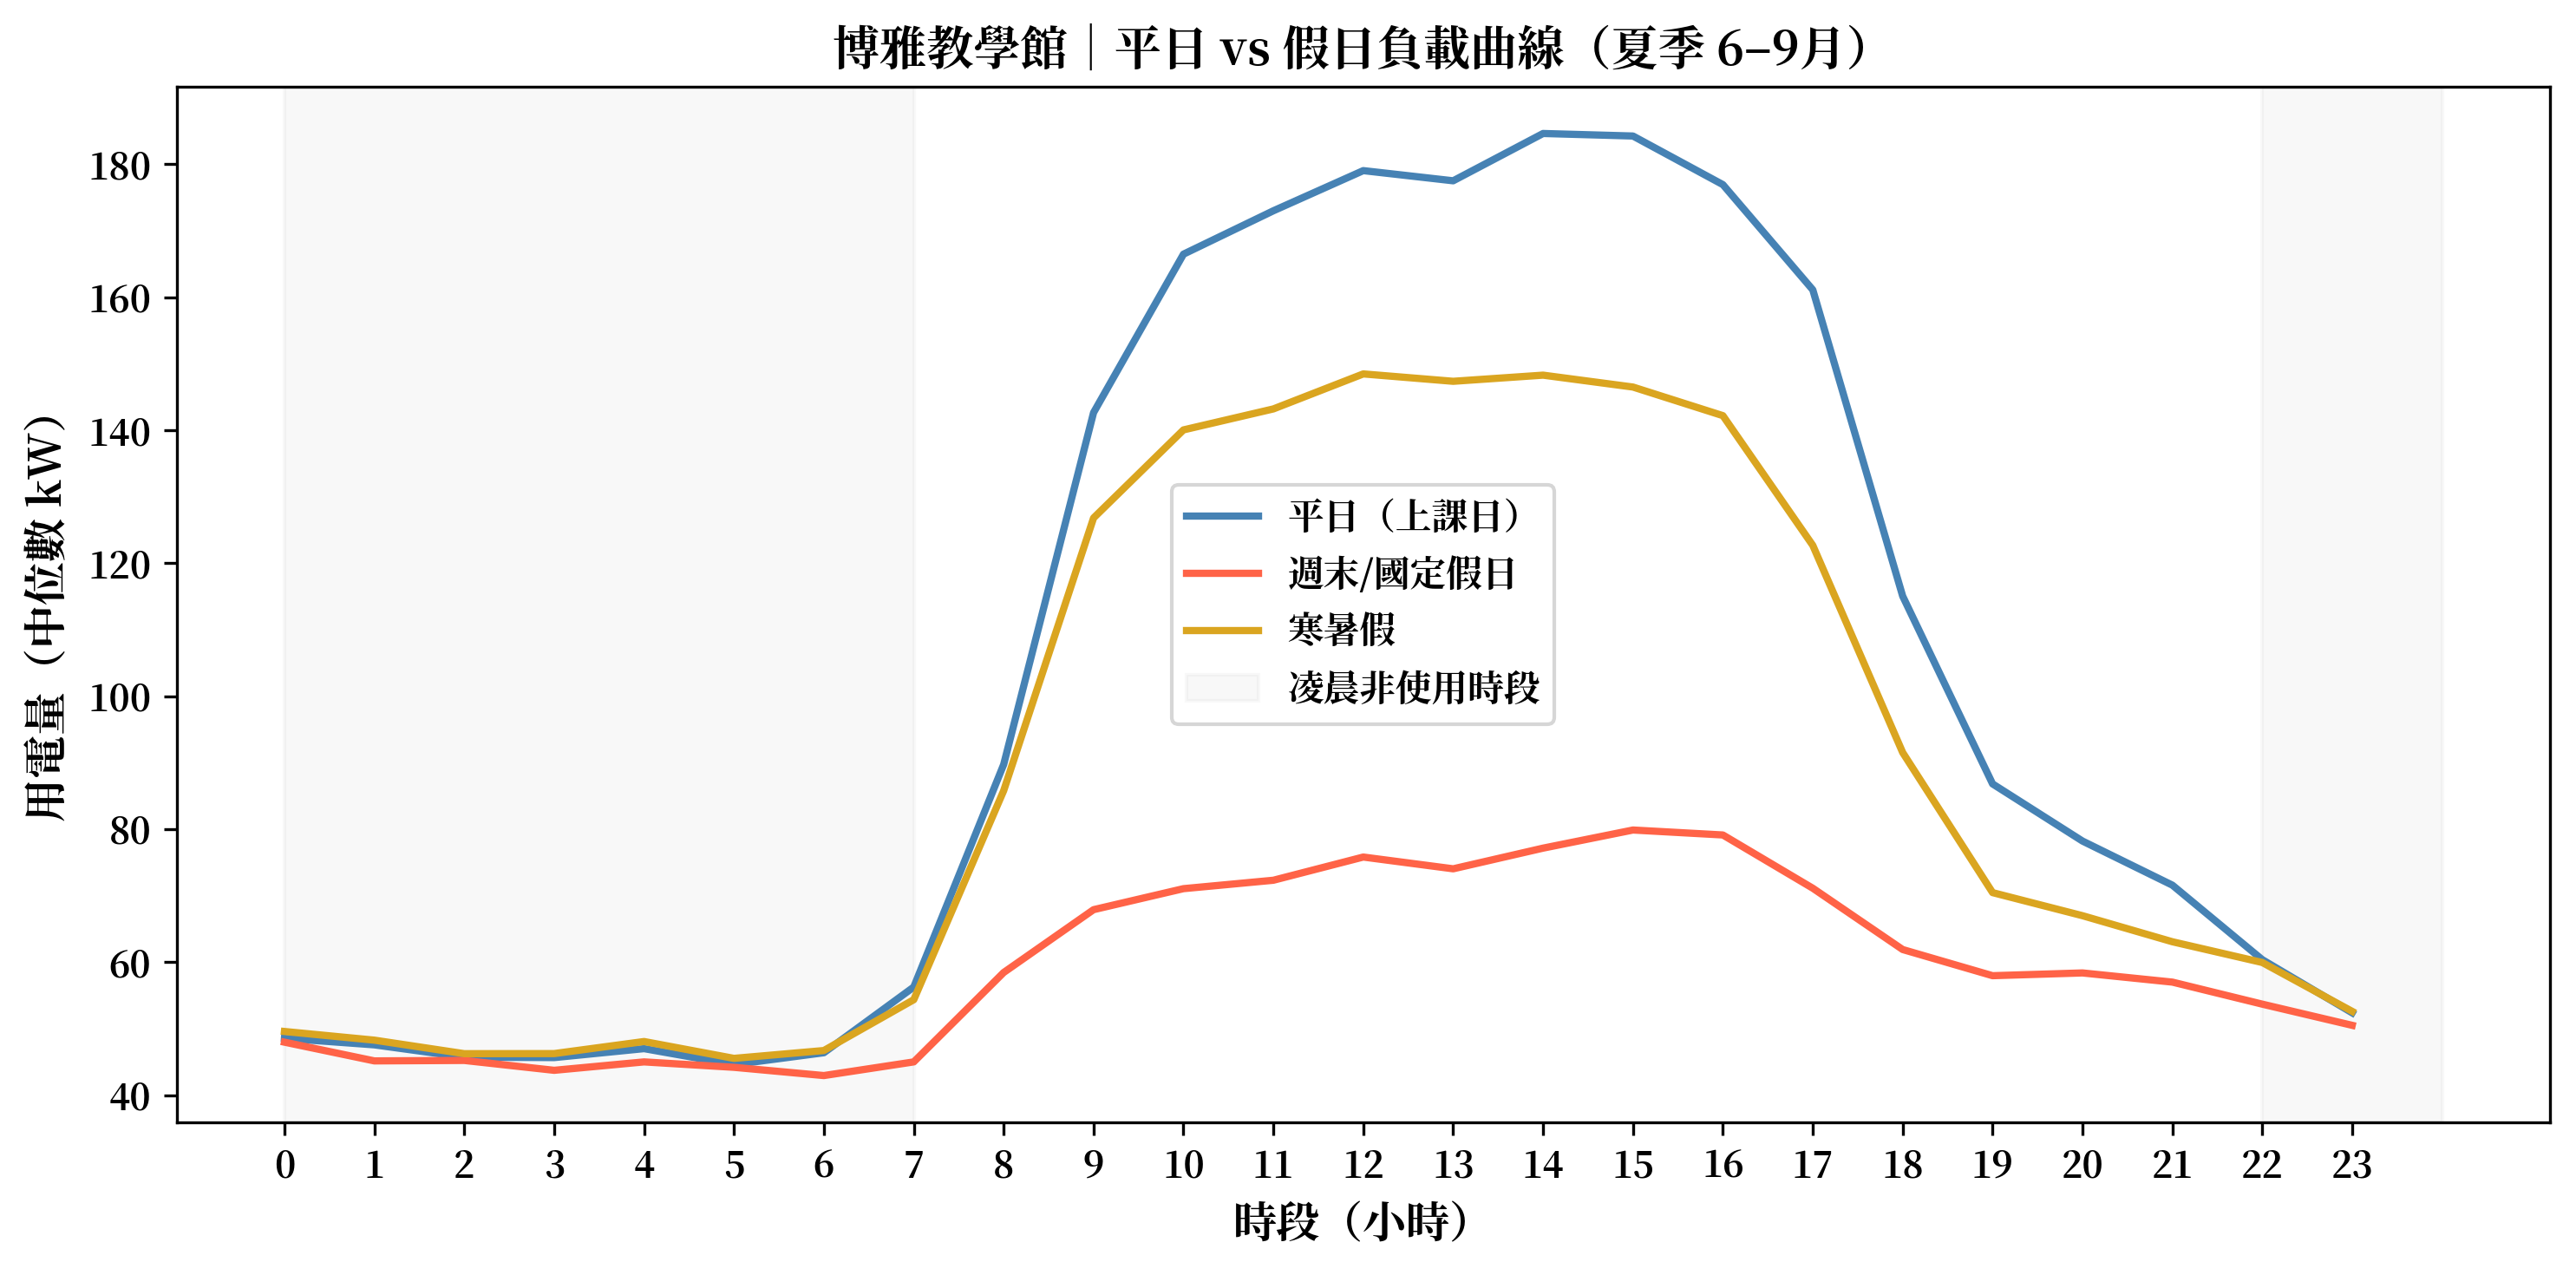


▶ 若假日（紅線）用電與平日（藍線）在日間差距不大，代表人離冷氣未關


In [32]:
# 以博雅為例（資料最完整的館舍）
boya_total = pd.concat([df_boya1[['kw']], df_boya2[['kw']], df_boya3[['kw']], df_boya4[['kw']]]).groupby(level=0)['kw'].sum().to_frame(name='kw')
boya_total['DayType'] = boya_total.index.map(get_day_type)
boya_total['hour'] = boya_total.index.hour
# 只取夏季（6–9月）讓冷氣效果最明顯
boya_summer = boya_total[boya_total.index.month.isin([6,7,8,9])]

dt_labels = {0: '平日（上課日）', 1: '過年', 2: '週末/國定假日', 3: '寒暑假'}
fig, ax = plt.subplots(figsize=(10, 5), dpi = 300)
colors = {0: 'steelblue', 2: 'tomato', 3: 'goldenrod'}

for dt, color in colors.items():
    grp = boya_summer[boya_summer['DayType'] == dt].groupby('hour')['kw'].median()
    ax.plot(grp.index, grp.values, label=dt_labels[dt], color=color, linewidth=2)

ax.set_xlabel('時段（小時）', fontsize=12)
ax.set_ylabel('用電量（中位數 kW）', fontsize=12)
ax.set_title('博雅教學館｜平日 vs 假日負載曲線（夏季 6–9月）', fontsize=13)
ax.axvspan(0, 7, alpha=0.05, color='gray', label='凌晨非使用時段')
ax.axvspan(22, 24, alpha=0.05, color='gray')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('cleaned_data/load_curve_daytype.png', dpi=300)
plt.show()
print("\n▶ 若假日（紅線）用電與平日（藍線）在日間差距不大，代表人離冷氣未關")


### 5. 年度用電趨勢（2016–2025）

目的：確認用電是否有改善趨勢；若無，強化「需要主動介入」的政策論點


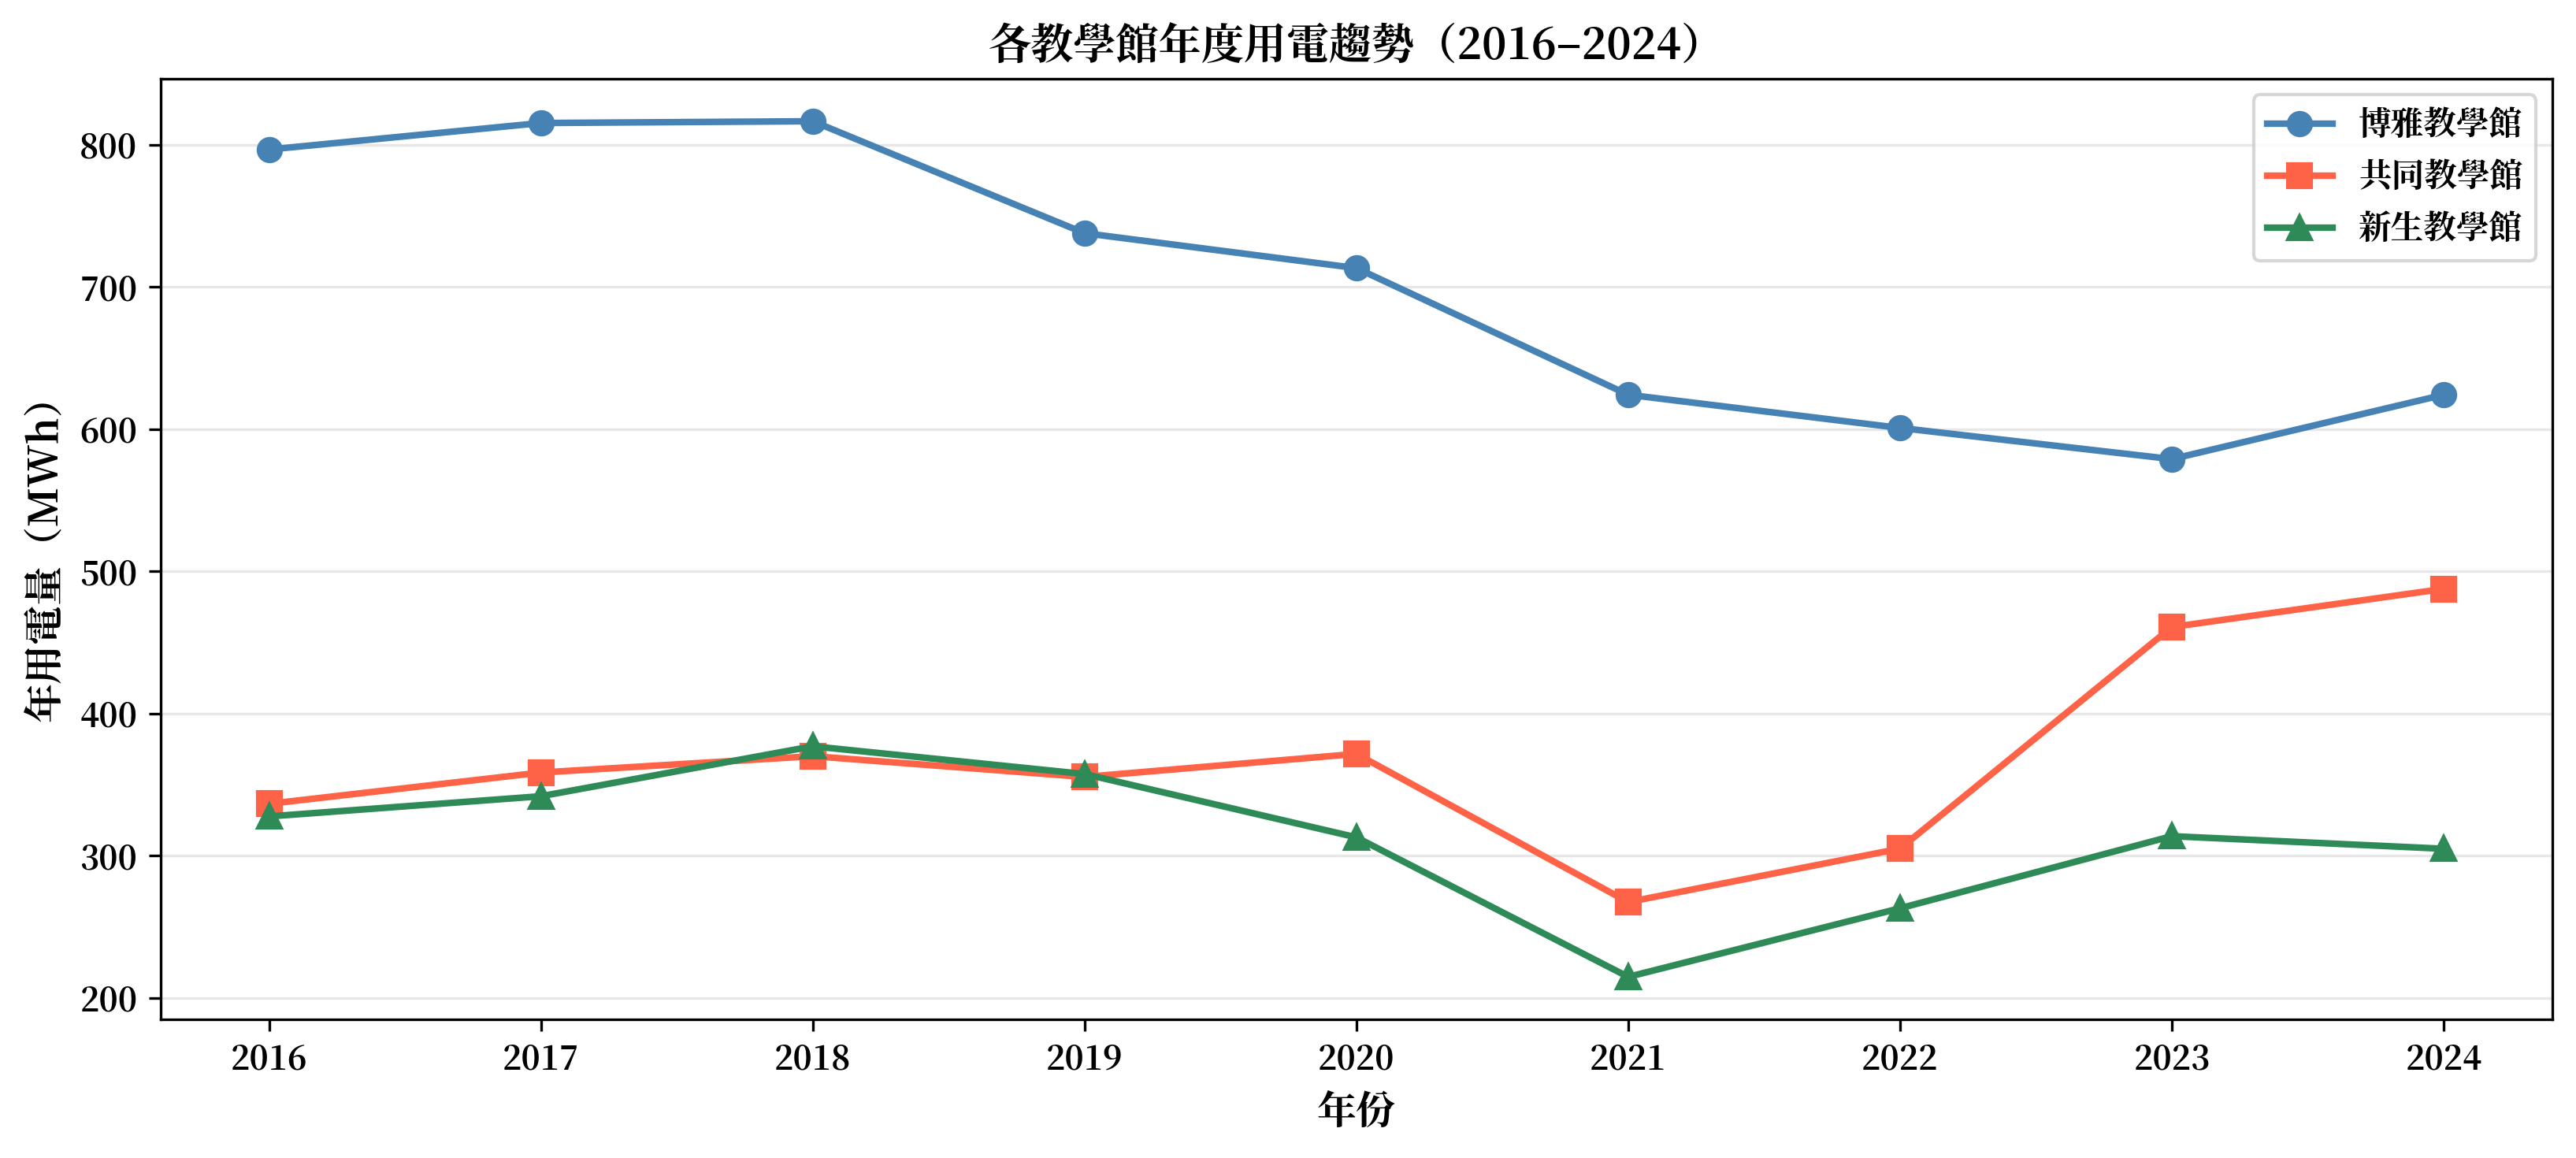

In [31]:
buildings_trend = {
    '博雅': pd.concat([df_boya1[['kw']], df_boya2[['kw']], df_boya3[['kw']], df_boya4[['kw']]]).groupby(level=0)['kw'].sum(),
    '共同': df_gongtong['kw'],
    '新生': df_xinsheng['kw'],
}

fig, ax = plt.subplots(figsize=(11, 5), dpi = 300)
markers = {'博雅': 'o', '共同': 's', '新生': '^'}
colors_t = {'博雅': 'steelblue', '共同': 'tomato', '新生': 'seagreen'}

for name, series in buildings_trend.items():
    annual = series.resample('YE').sum() / 1000  # 轉成 MWh
    # 只取完整年份（2016–2024）
    annual = annual[(annual.index.year >= 2016) & (annual.index.year <= 2024)]
    ax.plot(annual.index.year, annual.values,
            marker=markers[name], label=f'{name}教學館',
            color=colors_t[name], linewidth=2, markersize=7)

ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('年用電量（MWh）', fontsize=12)
ax.set_title('各教學館年度用電趨勢（2016–2024）', fontsize=13)
ax.set_xticks(range(2016, 2025))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cleaned_data/annual_trend.png', dpi=300)
plt.show()
